In [1]:
%%writefile requirements.txt
# Cuántico
qiskit
qiskit-machine-learning

# Deep learning (solo notebook 03)
torch
torchvision

# Científico / datos / gráficos
numpy
pandas
matplotlib

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt

# E6 · Expresibilidad y capacidad de entrelazamiento de los circuitos del TFM

**Notebook 01 — métricas intrínsecas del circuito.**

Este experimento cuantifica la calidad intrínseca de los circuitos parametrizados (PQC) usados en la clasificación de ruido mixto, con los dos descriptores de:

> Sim, S., Johnson, P. D., & Aspuru-Guzik, A. (2019). *Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms*. **Adv. Quantum Technol.** 2, 1900070. (arXiv:1905.10876)

El marco de encoding / feature maps / kernels sigue el curso [IBM Quantum Machine Learning](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/introduction).

## Definiciones

**Expresibilidad.** Se muestrean pares de parámetros $\theta,\phi$ y se calcula la fidelidad $F=|\langle\psi(\theta)|\psi(\phi)\rangle|^2$. La distribución empírica $P_{\text{PQC}}(F)$ se compara con la de estados aleatorios de Haar,
$$P_{\text{Haar}}(F)=(N-1)(1-F)^{N-2},\quad N=2^n,$$
mediante la divergencia de Kullback-Leibler:
$$\text{Expr}=D_{KL}\big(P_{\text{PQC}}(F)\,\|\,P_{\text{Haar}}(F)\big).$$
**KL menor $\Rightarrow$ más expresivo** (la distribución del circuito se acerca a la de Haar).

**Capacidad de entrelazamiento (Meyer-Wallach).**
$$Q=\frac{2}{n}\sum_{k=1}^{n}\big(1-\operatorname{Tr}\rho_k^2\big),$$
promediada sobre parámetros aleatorios, con $\rho_k$ la matriz densidad reducida del qubit $k$. $Q\in[0,1]$ (0 = estado producto, 1 = máximamente entrelazado).

Toda la lógica está en `qexpr.py` (mismo directorio).

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
import qexpr as qx

# --- Configuración ---
SEED = 42
N_SAMPLES = 2000      # el paper usa ~5000; súbelo para las figuras finales de la memoria
N_BINS = 75

# Salida con la convención estable E6_* del repo TFM-EXPERIMENTS (la memoria .tex la referencia).
OUTPUT_DIR = os.path.abspath(os.path.join('..', '..', 'TFM-EXPERIMENTS', 'outputs'))
TABLES_DIR = os.path.join(OUTPUT_DIR, 'tables')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Tablas  ->', TABLES_DIR)
print('Figuras ->', FIGURES_DIR)

Tablas  -> /TFM-EXPERIMENTS/outputs/tables
Figuras -> /TFM-EXPERIMENTS/outputs/figures


## 1. Circuito de producción

El del pipeline HQNN (`Hybrid CNN-QNN.ipynb`): `zz_feature_map(4, full, reps=1)` + `real_amplitudes(4, reverse_linear, reps=1)`.

In [4]:
!pip install pylatexenc

{'feature_map': 'zz', 'ansatz': 'real_amplitudes', 'n_qubits': 4, 'reps': 1, 'n_params': 12, 'depth': 22}


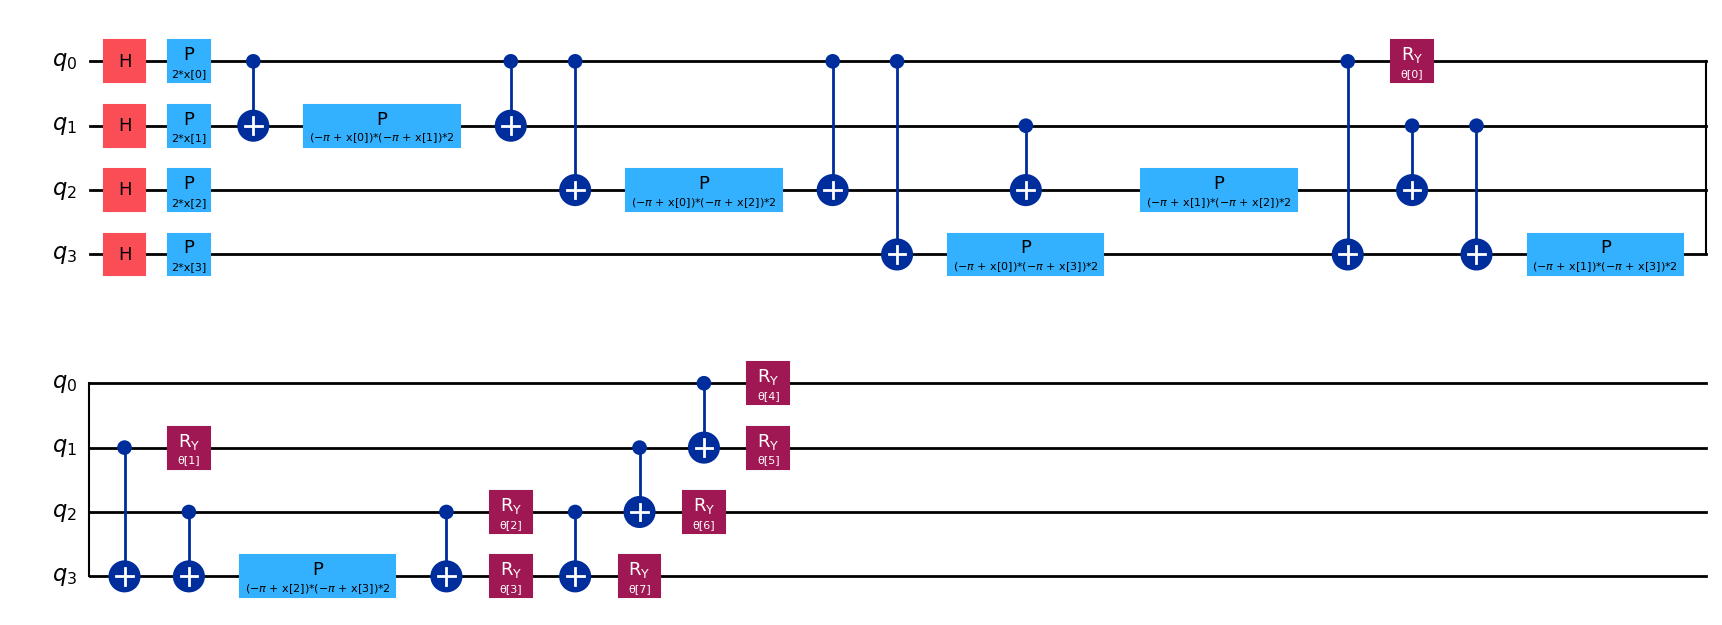

In [5]:
qc_prod, info_prod = qx.build_pqc('zz', 'real_amplitudes', n_qubits=4, reps=1,
                                  fm_entanglement='full', ansatz_entanglement='reverse_linear')
print(info_prod)
qc_prod.draw('mpl')

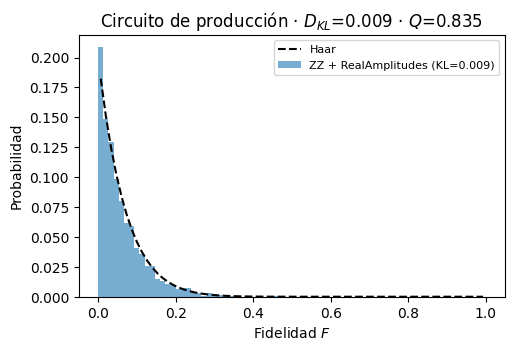

Expresibilidad D_KL = 0.0089  (menor = mejor)
Entrelazamiento  Q   = 0.8350 ± 0.1015


In [6]:
fids = qx.sample_fidelities(qc_prod, n_samples=N_SAMPLES, seed=SEED)
q_mean, q_std = qx.meyer_wallach_Q(qc_prod, n_samples=N_SAMPLES, seed=SEED)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
_, kl = qx.plot_fidelity_histogram(fids, 4, ax=ax, label='ZZ + RealAmplitudes', n_bins=N_BINS)
ax.set_title(f'Circuito de producción · $D_{{KL}}$={kl:.3f} · $Q$={q_mean:.3f}')
plt.show()
print(f'Expresibilidad D_KL = {kl:.4f}  (menor = mejor)')
print(f'Entrelazamiento  Q   = {q_mean:.4f} ± {q_std:.4f}')

## 2. Grid de ablación E6

Feature map $\in\{$`zz`, `pauli`$\}$ × ansatz $\in\{$`real_amplitudes`, `efficient_su2`$\}$ × qubits $\in\{4,6\}$ (`reps=1`). Se mide el estado completo *feature map + ansatz* (el que realmente prepara el modelo).

In [7]:
configs = [(fm, an, nq)
           for fm in ['zz', 'pauli']
           for an in ['real_amplitudes', 'efficient_su2']
           for nq in [4, 6]]

rows = []
for fm, an, nq in configs:
    qc, _ = qx.build_pqc(fm, an, n_qubits=nq, reps=1)
    d = qx.descriptors(qc, nq, n_samples=N_SAMPLES, n_bins=N_BINS, seed=SEED)
    d.update({'feature_map': fm, 'ansatz': an, 'circuit': f'{fm}+{an} ({nq}q)'})
    rows.append(d)
    print(f"{d['circuit']:28s}  KL={d['expressibility_kl']:.3f}  Q={d['entangling_Q']:.3f}  "
          f"(n_params={d['n_params']}, depth={d['depth']})")

df = pd.DataFrame(rows)[['circuit', 'feature_map', 'ansatz', 'n_qubits', 'n_params',
                         'depth', 'expressibility_kl', 'entangling_Q', 'entangling_Q_std']]
df

zz+real_amplitudes (4q)       KL=0.009  Q=0.835  (n_params=12, depth=22)
zz+real_amplitudes (6q)       KL=0.001  Q=0.949  (n_params=18, depth=36)
zz+efficient_su2 (4q)         KL=0.008  Q=0.830  (n_params=20, depth=24)
zz+efficient_su2 (6q)         KL=0.003  Q=0.950  (n_params=30, depth=38)
pauli+real_amplitudes (4q)    KL=0.020  Q=0.630  (n_params=12, depth=31)
pauli+real_amplitudes (6q)    KL=0.024  Q=0.762  (n_params=18, depth=45)
pauli+efficient_su2 (4q)      KL=0.007  Q=0.699  (n_params=20, depth=33)
pauli+efficient_su2 (6q)      KL=0.013  Q=0.801  (n_params=30, depth=47)


,circuit,feature_map,ansatz,n_qubits,n_params,depth,expressibility_kl,entangling_Q,entangling_Q_std
0,zz+real_amplitudes (4q),zz,real_amplitudes,4,12,22,0.008928,0.834993,0.101534
1,zz+real_amplitudes (6q),zz,real_amplitudes,6,18,36,0.001004,0.949018,0.039754
2,zz+efficient_su2 (4q),zz,efficient_su2,4,20,24,0.007948,0.830142,0.104298
3,zz+efficient_su2 (6q),zz,efficient_su2,6,30,38,0.002525,0.949953,0.036427
4,pauli+real_amplitudes (4q),pauli,real_amplitudes,4,12,31,0.020220,0.630375,0.177257
5,pauli+real_amplitudes (6q),pauli,real_amplitudes,6,18,45,0.024332,0.761830,0.125084
6,pauli+efficient_su2 (4q),pauli,efficient_su2,4,20,33,0.007032,0.698853,0.163617
7,pauli+efficient_su2 (6q),pauli,efficient_su2,6,30,47,0.013429,0.800506,0.111760


In [8]:
# Guardar tablas (nombres estables que la memoria referencia)
df.to_csv(os.path.join(TABLES_DIR, 'E6_circuit_descriptors.csv'), index=False)
df[['circuit', 'n_qubits', 'n_params', 'depth', 'expressibility_kl']].to_csv(
    os.path.join(TABLES_DIR, 'E6_expressibility.csv'), index=False)
df[['circuit', 'n_qubits', 'n_params', 'entangling_Q', 'entangling_Q_std']].to_csv(
    os.path.join(TABLES_DIR, 'E6_entangling.csv'), index=False)
print('Guardado: E6_circuit_descriptors.csv, E6_expressibility.csv, E6_entangling.csv')

Guardado: E6_circuit_descriptors.csv, E6_expressibility.csv, E6_entangling.csv


## 3. Gráficas comparativas

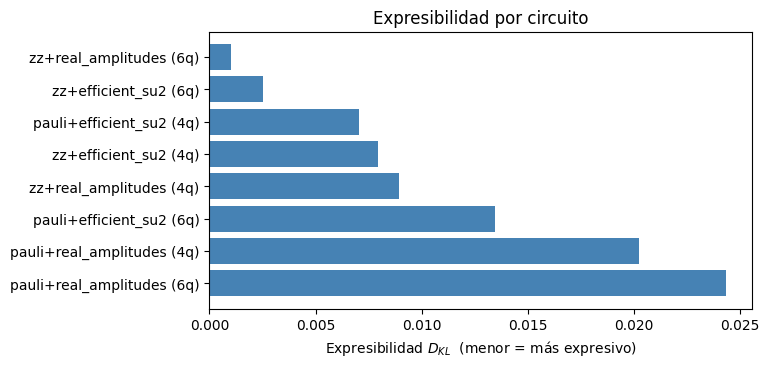

In [9]:
dfx = df.sort_values('expressibility_kl')
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(dfx['circuit'], dfx['expressibility_kl'], color='steelblue')
ax.set_xlabel('Expresibilidad $D_{KL}$  (menor = más expresivo)')
ax.invert_yaxis()
ax.set_title('Expresibilidad por circuito')
qx.savefig(fig, os.path.join(FIGURES_DIR, 'E6_expressibility_bars.png'))
plt.show()

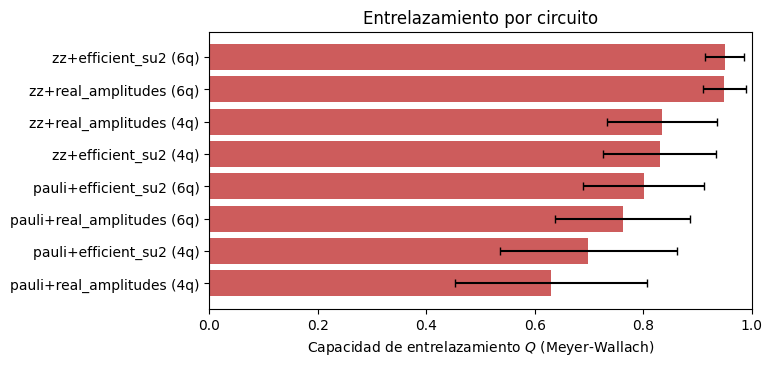

In [10]:
dfe = df.sort_values('entangling_Q', ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(dfe['circuit'], dfe['entangling_Q'], xerr=dfe['entangling_Q_std'],
        color='indianred', capsize=3)
ax.set_xlabel('Capacidad de entrelazamiento $Q$ (Meyer-Wallach)')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title('Entrelazamiento por circuito')
qx.savefig(fig, os.path.join(FIGURES_DIR, 'E6_entangling_bars.png'))
plt.show()

## 4. Saturación de la expresibilidad con la profundidad

Reproduce el hallazgo del paper: la expresibilidad mejora (KL baja) al aumentar `reps` y luego **satura**. Se compara el ansatz solo frente al circuito completo con encoding.

reps=1: KL_ansatz=0.310  KL_full=0.009
reps=2: KL_ansatz=0.181  KL_full=0.007
reps=3: KL_ansatz=0.131  KL_full=0.009
reps=4: KL_ansatz=0.110  KL_full=0.008
reps=5: KL_ansatz=0.141  KL_full=0.011


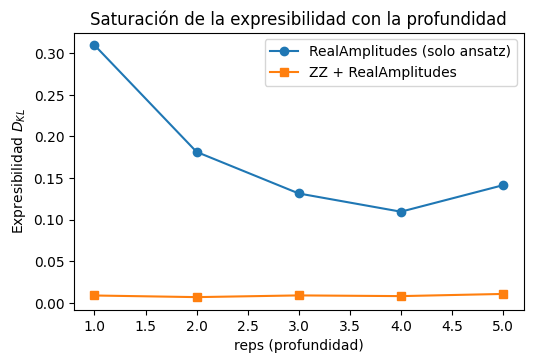

In [11]:
reps_list = [1, 2, 3, 4, 5]
kl_ansatz, kl_full = [], []
for r in reps_list:
    qa, _ = qx.build_pqc(None, 'real_amplitudes', n_qubits=4, reps=r, include_feature_map=False)
    kl_ansatz.append(qx.expressibility_kl(qx.sample_fidelities(qa, N_SAMPLES, SEED), 4, N_BINS)[0])
    qf, _ = qx.build_pqc('zz', 'real_amplitudes', n_qubits=4, reps=r)
    kl_full.append(qx.expressibility_kl(qx.sample_fidelities(qf, N_SAMPLES, SEED), 4, N_BINS)[0])
    print(f'reps={r}: KL_ansatz={kl_ansatz[-1]:.3f}  KL_full={kl_full[-1]:.3f}')

fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(reps_list, kl_ansatz, 'o-', label='RealAmplitudes (solo ansatz)')
ax.plot(reps_list, kl_full, 's-', label='ZZ + RealAmplitudes')
ax.set_xlabel('reps (profundidad)')
ax.set_ylabel('Expresibilidad $D_{KL}$')
ax.set_title('Saturación de la expresibilidad con la profundidad')
ax.legend()
qx.savefig(fig, os.path.join(FIGURES_DIR, 'E6_expressibility_vs_reps.png'))
plt.show()

## 5. Histogramas de fidelidad frente a Haar

Cuanto más se ajusta el histograma del circuito a la curva de Haar (línea discontinua), más expresivo es.

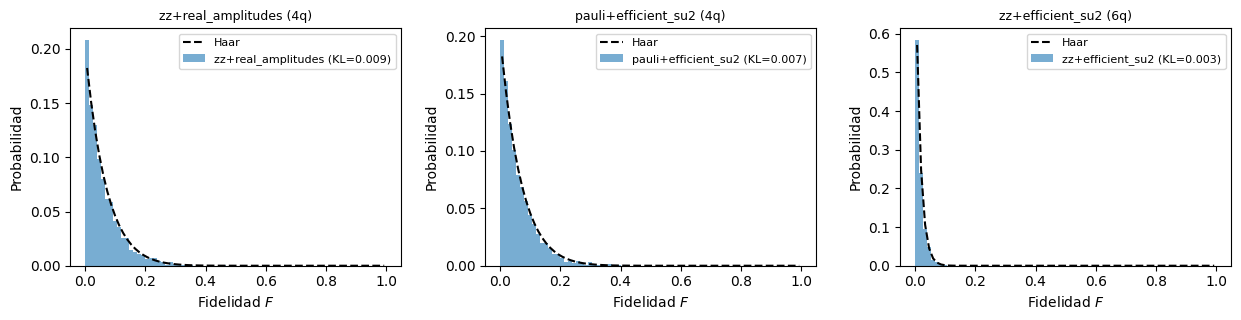

In [12]:
sel = [('zz', 'real_amplitudes', 4), ('pauli', 'efficient_su2', 4), ('zz', 'efficient_su2', 6)]
fig, axes = plt.subplots(1, len(sel), figsize=(4.2 * len(sel), 3.3))
for ax, (fm, an, nq) in zip(axes, sel):
    qc, _ = qx.build_pqc(fm, an, n_qubits=nq, reps=1)
    f = qx.sample_fidelities(qc, N_SAMPLES, SEED)
    qx.plot_fidelity_histogram(f, nq, ax=ax, label=f'{fm}+{an}', n_bins=N_BINS)
    ax.set_title(f'{fm}+{an} ({nq}q)', fontsize=9)
fig.tight_layout()
qx.savefig(fig, os.path.join(FIGURES_DIR, 'E6_fidelity_histograms.png'))
plt.show()

## Interpretación (para la memoria)

- **KL menor = más expresivo**; **Q mayor = más entrelazamiento**.
- Se espera que `efficient_su2` sea más expresivo que `real_amplitudes` (más parámetros y puertas RZ) pero con más riesgo de *barren plateaus* al crecer qubits/reps.
- La expresibilidad **satura** con la profundidad (sección 4): añadir `reps` deja de compensar.
- Estos descriptores justifican, junto al notebook 03 (correlación con accuracy), la elección del circuito de producción en el TFM.

Artefactos generados en `TFM-EXPERIMENTS/outputs/`:
`E6_circuit_descriptors.csv`, `E6_expressibility.csv`, `E6_entangling.csv`,
`E6_expressibility_bars.png`, `E6_entangling_bars.png`, `E6_expressibility_vs_reps.png`, `E6_fidelity_histograms.png`.